# CUNY Salary Data Analysis

In [1]:
from google.colab import files

uploaded= files.upload()

Saving Salaries.csv to Salaries.csv


In [2]:
import pandas as pd
df= pd.read_csv('Salaries.csv')

In [3]:
import numpy as np


- data wrangling - renaming columns, subsetting columns, handling
missing data, etc.

In [4]:
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
rank,0
discipline,0
yrs.since.phd,0
yrs.service,0
sex,0
salary,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     397 non-null    int64 
 1   rank           397 non-null    object
 2   discipline     397 non-null    object
 3   yrs.since.phd  397 non-null    int64 
 4   yrs.service    397 non-null    int64 
 5   sex            397 non-null    object
 6   salary         397 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 21.8+ KB


In [7]:
df.dtypes

,0
Unnamed: 0,int64
rank,object
discipline,object
yrs.since.phd,int64
yrs.service,int64
sex,object
salary,int64


In [8]:
#Numbers of rows and columns
df.shape

(397, 7)

In [9]:
df.columns

Index(['Unnamed: 0', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service',
       'sex', 'salary'],
      dtype='object')

In [10]:
df['Unnamed: 0']

,Unnamed: 0
0,1
1,2
2,3
3,4
4,5
...,...
392,393
393,394
394,395
395,396


In [106]:
df_raw= df.copy()
df_clean= df_raw.copy()

In [107]:
df_clean.rename(columns={'Unnamed: 0': 'id'}, inplace= True)

In [15]:
df_clean

,id,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500
...,...,...,...,...,...,...,...
392,393,Prof,A,33,30,Male,103106
393,394,Prof,A,31,19,Male,150564
394,395,Prof,A,42,25,Male,101738
395,396,Prof,A,25,15,Male,95329


In [108]:
df_clean['salary']

,salary
0,139750
1,173200
2,79750
3,115000
4,141500
...,...
392,103106
393,150564
394,101738
395,95329


In [109]:
df_clean['rank'].unique()

array(['Prof', 'AsstProf', 'AssocProf'], dtype=object)

In [110]:
df_analysis=df_clean[['id','rank','salary']] #subset the dataset
print(df_analysis.head())

   id      rank  salary
0   1      Prof  139750
1   2      Prof  173200
2   3  AsstProf   79750
3   4      Prof  115000
4   5      Prof  141500


- data exploration - mean/median of all salaries, median salary by
gender and/or rank/title, etc.


In [100]:
#Mean salary
df_clean['salary'].mean()

np.float64(113706.45843828715)

In [76]:
#Proportion of male and female in the sample
df_clean['sex'].value_counts('id')

,proportion
sex,
Male,0.901763
Female,0.098237


In [101]:
#Mean salary polished
mean_salary= df_clean['salary'].mean()
print(f"The mean salary is ${mean_salary:,.0f}") #Format as dollars with commas and zero decimals

The mean salary is $113,706


In [102]:
#Mean salary by sex
mean_salary_by_sex= df_clean.groupby('sex')['salary'].mean()
print(f"Mean salary by {mean_salary_by_sex}")

Mean salary by sex
Female    101002.410256
Male      115090.418994
Name: salary, dtype: float64


In [99]:
#Median salary
df_clean['salary'].median()

107300.0

In [95]:
#Median salary by sex
#Note: the map. method applies the funcion lamba to all the values in this case to both female and male.
median_salary_by_sex= df_clean.groupby('sex')['salary'].median()
median_salary_by_sex.map(lambda x: f" ${x:,.0f}") #Take each value, call it x, and format it as dollars with commas and zero decimal places.

,salary
sex,
Female,"$103,750"
Male,"$108,043"


In [39]:
#Correlation between Salary and Year since Phd
df_clean['salary'].corr(df_clean['yrs.since.phd'])


np.float64(0.41923110680257986)

- data visualizations - show some stats

<Axes: title={'center': 'Proportion of each rank in the sample'}, xlabel='rank', ylabel='proportion'>

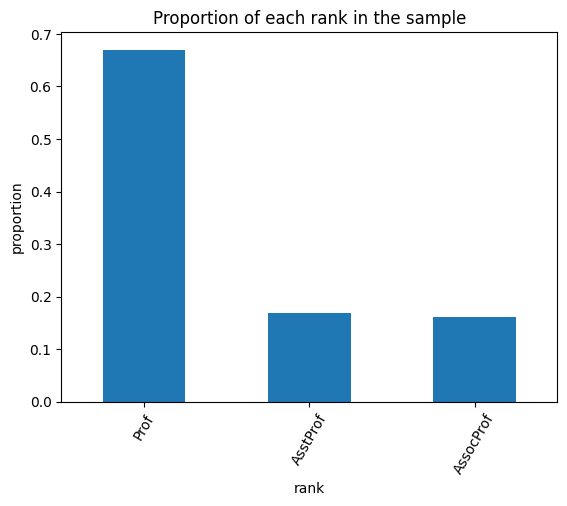

In [89]:
#Bar Chart representing the frequency distribution of the ranks
df_clean['rank'].value_counts('id').sort_values(ascending=False).plot(kind='bar', title='Proportion of each rank in the sample',ylabel='proportion',rot=60)

<Axes: title={'center': 'Median salary by sex'}, xlabel='sex', ylabel='salary in $'>

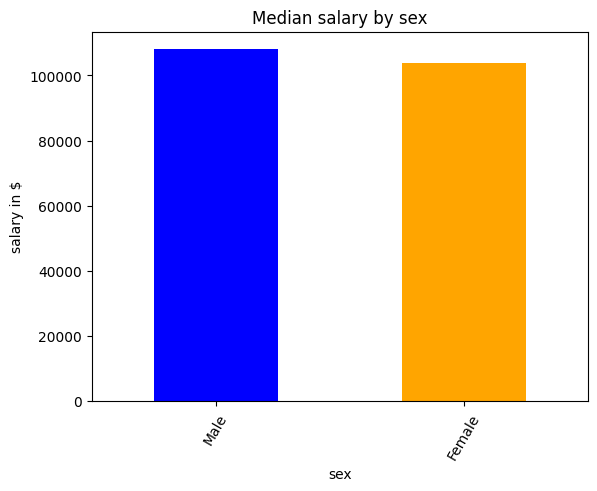

In [114]:
#Bar chart representing the median salary by sex
df_clean.groupby('sex')['salary'].median().sort_values(ascending=False).plot(kind='bar',title='Median salary by sex',ylabel='salary in $',rot=60, color=['blue','orange'])

<Axes: title={'center': 'Distribution of salary in the sample'}>

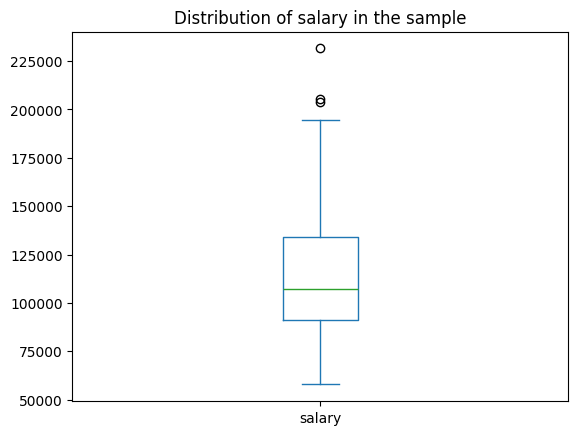

In [91]:
#Box and whisker of salary
df["salary"].plot(
    kind="box",
    title="Distribution of salary in the sample"
)

<Axes: title={'center': 'Correlation between salary and time passes since obtaining a Phd'}, xlabel='salary in $', ylabel='years since Phd'>

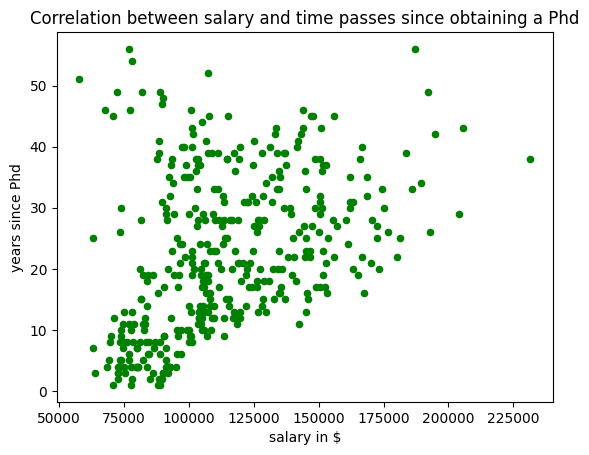

In [115]:
#Scatter plot of salary and Years since Phd
df.plot(kind='scatter', x='salary', y='yrs.since.phd', xlabel='salary in $',ylabel='years since Phd',
  title='Correlation between salary and time passes since obtaining a Phd', color='green')

- conclusions - what did you discover?
-- In this dataset each row represents one professor with a specific rank, salary, accounting for the year since when they obtain their Phd, and the years of service. The sample has a total of 396 observations and does not contain any missing value. There is a significant higher number of man representing 90% of the sample, versus women representing 10%. The sample includes professors, assistent professors, and associate professors. The majority of the sample is the rank of a professor (more than 65%).
-- The brief analysis foused on salary shows that salary is right-skewed with high-earners pulling the mean. The box and wisker clearily shows the presence of these high-earner outliers. For this reason the median salary (\$107,300) is a better description of central tendency and is lower than the mean (\$113,706). Additionally, the analysis breaks down the meadian salary based on sex, showing how women receive a lower salary (\$103,750) than man (\$108,043). Finally, the correlation analysis revealed that there is a positive moderate correlation (r=0.419) between salary and years since when a professor has obtain a Phd. Meaning that as a general trend salary increases as more years have passes since obtaining a Phd. This makes sense if we consider years since a Phd as a proxy for seniority.